Original X shape:  (19020, 10)
Binarized X shape: (19020, 114)
Binning map: {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], 1: [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], 2: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66], 3: [67], 4: [68, 69, 70, 71], 5: [72, 73], 6: [74, 75, 76, 77, 78, 79, 80, 81], 7: [82], 8: [83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104], 9: [105, 106, 107, 108, 109, 110, 111, 112, 113]}
Best objective: 3123 (0.164196)
Objective bound: 3154
Minimum objective: 3100
Cache sizes - Greedy: 342652, Lickety: 1685698, Trie: 0, Trie cache: OFF

Minimum objective: 3100
Rashomon set size: 1474
Objective = 3100, Count = 1
Objective = 3102, Count = 1
Objective = 3104, Count = 2
Objective = 3105, Count = 4
Objective = 3106, Count = 2
Objective = 3107, Count = 2
Objective = 3108, Count = 1
Objective = 3110,

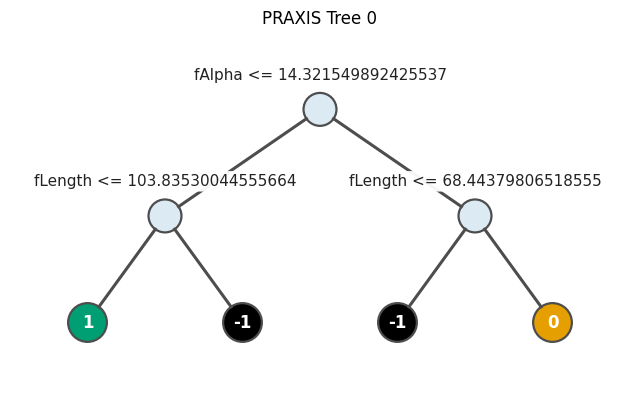

Tree 1473
Objective (raw):        3154
Objective (normalized): 0.165825
Training accuracy:      0.9509
Num deferrals:          8727
Deferral rate:          0.4588
First 10 predictions:   [1 1 0 1 1 1 1 1 1 1]
First 10 raw actions:   [99  1  0  1  1  1  1  1  1  1]
Number of leaves:       5
Root-to-leaf paths:
[+99, +22, +88] -> predict 1
[+99, +22, -88] -> defer
[+99, -22] -> predict 0
[-99, +6] -> defer
[-99, -6] -> predict 0


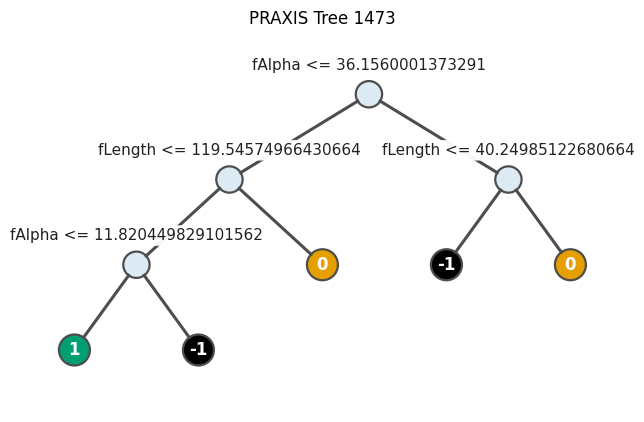

Saved magic_deferral_rashomon_builder.html
Open the HTML file directly in your browser.
Saved magic_deferral_praxis_payload.json
You can also upload this JSON file at: https://interactive-tree-builder.vercel.app
Best objective: 3141 (0.165142)
Objective bound: 3172
Minimum objective: 3100
Cache sizes - Greedy: 468770, Lickety: 3712199, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 1 / 3 with 45320 trees
Best objective: 3131 (0.164616)
Objective bound: 3162
Minimum objective: 3099
Cache sizes - Greedy: 317862, Lickety: 1362083, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 2 / 3 with 2147 trees
Best objective: 3146 (0.165405)
Objective bound: 3177
Minimum objective: 3103
Cache sizes - Greedy: 427486, Lickety: 3306720, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 3 / 3 with 9089 trees


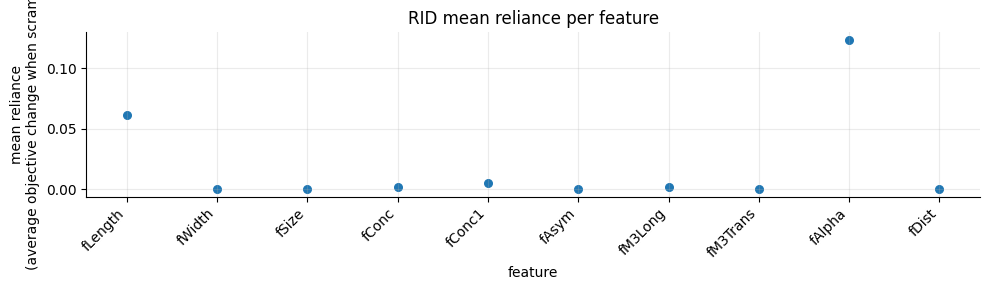

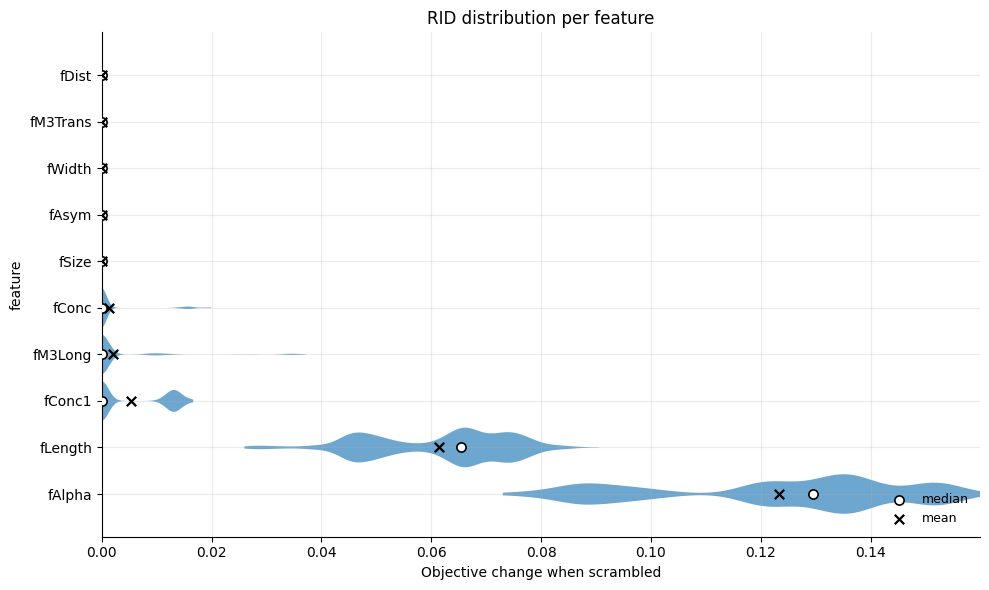

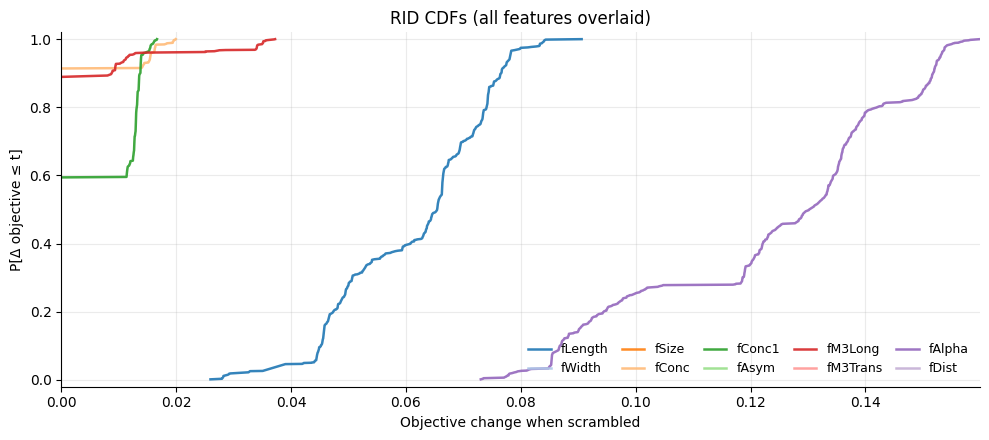

(<Figure size 1000x450 with 1 Axes>,
 <Axes: title={'center': 'RID CDFs (all features overlaid)'}, xlabel='Objective change when scrambled', ylabel='P[Δ objective ≤ t]'>)

In [1]:
# example with deferral
import numpy as np
from ucimlrepo import fetch_ucirepo
from praxis import PRAXIS, ThresholdGuessBinarizer


def accuracy(y_true, y_pred):
    return (np.asarray(y_true).astype(int) == np.asarray(y_pred).astype(int)).mean()


magic = fetch_ucirepo(id=159)
X_raw = magic.data.features.copy()
y_raw = magic.data.targets.copy()

y_col = y_raw.columns[0]
y = (y_raw[y_col] == "g").to_numpy(np.int64)

# deferral vector / black-box predictions.
# here we make deferral perfect by using the ground truth.
bb_pred = y.copy()


# binarize continuous features
enc = ThresholdGuessBinarizer(
    n_estimators=50,
    max_depth=2,
    random_state=0,
    column_elimination=False,
)

X = enc.fit_transform(X_raw, y).astype(np.uint8)

# maps each original raw feature to its binary threshold columns
binning_map = enc.feature_map()

print("Original X shape: ", X_raw.shape)
print("Binarized X shape:", X.shape)
print("Binning map:", binning_map)


# fit a Rashomon Set using PRAXIS with deferral
model = PRAXIS()

ETA_DEFER = 0.2  # penalty per deferred sample

model.fit(
    X,
    y,
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    multiplicative_slack=0,
    key_mode="hash",
    lookahead_k=1,

    # deferral
    use_deferral=True,
    eta_defer=ETA_DEFER,
    bb_pred=bb_pred,
)

print("\nMinimum objective:", model.get_min_objective())
print("Rashomon set size:", model.count_trees())

for obj, cnt in model.get_root_histogram():
    print(f"Objective = {obj}, Count = {cnt}")


# inspect first and last trees in the Rashomon set
num_trees = model.count_trees()

for tree_idx in [0, num_trees - 1]:
    print("=" * 60)
    print(f"Tree {tree_idx}")

    obj_raw, obj_norm = model.get_tree_objective(tree_idx)

    # resolved predictions: defer leaves use bb_pred, which here is y.
    preds = model.get_predictions(
        tree_idx,
        X,
        bb_pred=bb_pred,
    )

    # placeholder predictions: defer leaves show up as 99.
    preds_with_defer_marker = model.get_predictions(
        tree_idx,
        X,
        defer_placeholder=99,
    )

    num_deferrals = int(np.sum(preds_with_defer_marker == 99))
    defer_rate = num_deferrals / len(y)

    paths_str, leaf_preds = model.get_tree_paths_str(tree_idx)

    print(f"Objective (raw):        {obj_raw}")
    print(f"Objective (normalized): {obj_norm:.6f}")
    print(f"Training accuracy:      {accuracy(y, preds):.4f}")
    print(f"Num deferrals:          {num_deferrals}")
    print(f"Deferral rate:          {defer_rate:.4f}")
    print(f"First 10 predictions:   {preds[:10]}")
    print(f"First 10 raw actions:   {preds_with_defer_marker[:10]}")
    print(f"Number of leaves:       {len(paths_str)}")

    print("Root-to-leaf paths:")
    for path, pred in zip(paths_str, leaf_preds):
        action = "defer" if int(pred) == -1 else f"predict {int(pred)}"
        print(path, "->", action)

    model.plot_tree(
        tree_idx,
        feature_names=enc.get_feature_names_out(),
        title=f"PRAXIS Tree {tree_idx}",
        show=True,
    )

# save interactive Rashomon tree-builder HTML
model.save_builder_html(
    "magic_deferral_rashomon_builder.html",
    binarizer=enc,
    raw_feature_names=list(enc.feature_names_in_),
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    root_n=X.shape[0],
    eta_defer=ETA_DEFER,
)

print("Saved magic_deferral_rashomon_builder.html")
print("Open the HTML file directly in your browser.")


# optionally also save the portable JSON payload
model.save_builder_payload(
    "magic_deferral_praxis_payload.json",
    binarizer=enc,
    raw_feature_names=list(enc.feature_names_in_),
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    root_n=X.shape[0],
    eta_defer=ETA_DEFER,
)

print("Saved magic_deferral_praxis_payload.json")
print("You can also upload this JSON file at: https://interactive-tree-builder.vercel.app")

# compute and plot Rashomon Importance Distribution.
model.compute_rid(
    X,
    y,
    n_boot=3,
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    seed=0,
    binning_map=binning_map,

    # deferral
    use_deferral=True,
    eta_defer=ETA_DEFER,
    bb_pred=bb_pred,
)

feature_names = list(enc.feature_names_in_)

model.rid_plot_mean(feature_names=feature_names)
model.rid_plot_violin(feature_names=feature_names)
model.rid_plot_cdfs(feature_names=feature_names)

